IMPORT LIBRARIES

In [ ]:
import pandas as pd
import re
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import (
    Input, Embedding, Conv1D, GlobalMaxPooling1D,
    Dense, Dropout, SpatialDropout1D, BatchNormalization,
    Concatenate
)
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

LOAD DATASET

In [ ]:
file_path = "/content/data-đồ-án.xlsm"

df = pd.read_excel(file_path, engine="openpyxl")

df = df[["Comment", "Label"]].dropna()
df["Label"] = df["Label"].astype(str).str.strip().str.upper()

print("Dataset shape:", df.shape)

print("\nLabel distribution:")
print(df["Label"].value_counts())

display(df.head())

Dataset shape: (31460, 2)

Label distribution:
Label
POS    20093
NEG     6669
NEU     4698
Name: count, dtype: int64


,Comment,Label
0,Áo bao đẹp ạ!!,POS
1,Tuyệt vời !,POS
2,2day ao khong giong trong.,NEG
3,"Mùi thơm,bôi lên da mềm da.",POS
4,"Vải đẹp, dày dặn.",POS


TEXT PREPROCESSING

In [ ]:
def preprocess(text):
    text = str(text).lower()

    # Chuẩn hóa một số từ viết tắt phổ biến trong comment tiếng Việt
    replacements = {
        " ko ": " không ",
        " k ": " không ",
        " kh ": " không ",
        " hok ": " không ",
        " kg ": " không ",
        " dc ": " được ",
        " đc ": " được ",
        " sp ": " sản phẩm ",
        " ok ": " tốt ",
        " oke ": " tốt ",
    }

    text = " " + text + " "
    for k, v in replacements.items():
        text = text.replace(k, v)

    # Bỏ ký tự đặc biệt, giữ chữ tiếng Việt
    text = re.sub(r"[^\w\sÀ-ỹ]", " ", text)

    # Giảm ký tự lặp quá nhiều: đẹpppp -> đẹpp
    text = re.sub(r"(.)\1{2,}", r"\1\1", text)

    # Chuẩn hóa khoảng trắng
    text = re.sub(r"\s+", " ", text).strip()

    return text


df["clean_text"] = df["Comment"].apply(preprocess)

print("Before and after preprocessing:")
display(df[["Comment", "clean_text", "Label"]].head())

Before and after preprocessing:


,Comment,clean_text,Label
0,Áo bao đẹp ạ!!,áo bao đẹp ạ,POS
1,Tuyệt vời !,tuyệt vời,POS
2,2day ao khong giong trong.,2day ao khong giong trong,NEG
3,"Mùi thơm,bôi lên da mềm da.",mùi thơm bôi lên da mềm da,POS
4,"Vải đẹp, dày dặn.",vải đẹp dày dặn,POS


ENCODE LABELS

In [ ]:
encoder = LabelEncoder()

y = encoder.fit_transform(df["Label"])

print("Label mapping:")
for idx, label in enumerate(encoder.classes_):
    print(idx, "=>", label)

Label mapping:
0 => NEG
1 => NEU
2 => POS


TOKENIZATION AND PADDING

In [ ]:
max_words = 30000
max_len = 80

tokenizer = Tokenizer(
    num_words=max_words,
    oov_token="<OOV>"
)

tokenizer.fit_on_texts(df["clean_text"])

X = tokenizer.texts_to_sequences(df["clean_text"])

X = pad_sequences(
    X,
    maxlen=max_len,
    padding="post",
    truncating="post"
)

print("X shape:", X.shape)
print("Example sequence:")
print(X[0])

X shape: (31460, 80)
Example sequence:
[ 12 208   5  53   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0]


TRAIN / TEST SPLIT

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train size:", X_train.shape[0])
print("Test size:", X_test.shape[0])

Train size: 25168
Test size: 6292


 CLASS WEIGHT

In [ ]:
classes = np.unique(y_train)

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weight_dict = dict(zip(classes, class_weights))

print("Class weights:")
print(class_weight_dict)

Class weights:
{np.int64(0): np.float64(1.572508591065292), np.int64(1): np.float64(2.2317992373858297), np.int64(2): np.float64(0.521919455850027)}


 BUILD IMPROVED CNN MODEL

In [ ]:
embedding_dim = 128

inputs = Input(shape=(max_len,))

x = Embedding(
    input_dim=max_words,
    output_dim=embedding_dim
)(inputs)

x = SpatialDropout1D(0.2)(x)

x = Conv1D(
    filters=128,
    kernel_size=5,
    activation="relu",
    padding="same"
)(x)

x = GlobalMaxPooling1D()(x)

x = Dense(128, activation="relu")(x)
x = Dropout(0.3)(x)

x = Dense(64, activation="relu")(x)
x = Dropout(0.2)(x)

outputs = Dense(3, activation="softmax")(x)

model = Model(inputs=inputs, outputs=outputs)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 80)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_1 (Embedding)         │ (None, 80, 128)        │     3,840,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_1             │ (None, 80, 128)        │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 80, 128)        │        82,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_3          │ (None, 128)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,947,011 (15.06 MB)

 Trainable params: 3,947,011 (15.06 MB)

 Non-trainable params: 0 (0.00 B)

COMPILE MODEL

In [ ]:
model.compile(
    loss="sparse_categorical_crossentropy",
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
    metrics=["accuracy"]
)

CALLBACKS

In [ ]:
early_stop = EarlyStopping(
    monitor="val_accuracy",
    patience=4,
    mode="max",
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

TRAIN MODEL

In [ ]:
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=64,
    validation_split=0.1,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Epoch 1/20
354/354 ━━━━━━━━━━━━━━━━━━━━ 41s 110ms/step - accuracy: 0.7361 - loss: 0.6376 - val_accuracy: 0.7823 - val_loss: 0.5229 - learning_rate: 5.0000e-04
Epoch 2/20
354/354 ━━━━━━━━━━━━━━━━━━━━ 40s 107ms/step - accuracy: 0.8072 - loss: 0.4886 - val_accuracy: 0.7922 - val_loss: 0.5077 - learning_rate: 5.0000e-04
Epoch 3/20
354/354 ━━━━━━━━━━━━━━━━━━━━ 38s 107ms/step - accuracy: 0.8340 - loss: 0.4288 - val_accuracy: 0.7898 - val_loss: 0.5083 - learning_rate: 5.0000e-04
Epoch 4/20
354/354 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - accuracy: 0.8600 - loss: 0.3710
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
354/354 ━━━━━━━━━━━━━━━━━━━━ 42s 109ms/step - accuracy: 0.8587 - loss: 0.3754 - val_accuracy: 0.7863 - val_loss: 0.5299 - learning_rate: 5.0000e-04
Epoch 5/20
354/354 ━━━━━━━━━━━━━━━━━━━━ 38s 109ms/step - accuracy: 0.8903 - loss: 0.3078 - val_accuracy: 0.7747 - val_loss: 0.5658 - learning_rate: 2.5000e-04
Epoch 6/20
354/354 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/ste

In [ ]:
# ==========================================
# 12. CLASSIFICATION REPORT FOR CNN MODEL
# ==========================================

import numpy as np
import pandas as pd

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# ==========================================
# 1. PREDICT ON TEST SET
# ==========================================

y_pred_prob = model.predict(X_test)
y_pred = np.argmax(y_pred_prob, axis=1)

# ==========================================
# 2. ACCURACY
# ==========================================

accuracy = accuracy_score(y_test, y_pred)

print("==== CNN MODEL EVALUATION ====")
print(f"Test Accuracy: {accuracy:.4f}")

# ==========================================
# 3. CLASSIFICATION REPORT
# ==========================================

print("\n==== CLASSIFICATION REPORT ====")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=encoder.classes_,
        digits=4
    )
)

# ==========================================
# 5. CONFUSION MATRIX
# ==========================================

print("\n==== CONFUSION MATRIX ====")
print(confusion_matrix(y_test, y_pred))

197/197 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step
==== CNN MODEL EVALUATION ====
Test Accuracy: 0.7969

==== CLASSIFICATION REPORT ====
              precision    recall  f1-score   support

         NEG     0.6819    0.8388    0.7523      1334
         NEU     0.4207    0.2290    0.2966       939
         POS     0.8889    0.9157    0.9021      4019

    accuracy                         0.7969      6292
   macro avg     0.6638    0.6611    0.6503      6292
weighted avg     0.7751    0.7969    0.7799      6292


==== CONFUSION MATRIX ====
[[1119  119   96]
 [ 360  215  364]
 [ 162  177 3680]]


CALCULATE Main Metric, Precision, Recall, F1-score, Params, FPS, Parameters, Model Size, FLOPs, FPS / Inference Time

In [ ]:
import time
import os
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# ==========================================
# 1. PREDICT ON TEST SET
# ==========================================

y_pred_prob = model.predict(X_test, verbose=0)
y_pred = np.argmax(y_pred_prob, axis=1)

# ==========================================
# 2. PERFORMANCE METRICS
# ==========================================

main_metric = accuracy_score(y_test, y_pred)

precision = precision_score(y_test, y_pred, average="macro")
recall = recall_score(y_test, y_pred, average="macro")
f1 = f1_score(y_test, y_pred, average="macro")

# ==========================================
# 3. PARAMS / PARAMETERS
# ==========================================

total_params = model.count_params()
params_million = total_params / 1_000_000

# ==========================================
# MODEL SIZE
# ==========================================

model_path = "cnn_emotion_model.keras"
model.save(model_path)

model_size_mb = os.path.getsize(model_path) / (1024 * 1024)

print("Model Size:", f"{model_size_mb:.2f} MB")

# ==========================================
# 5. FPS / INFERENCE TIME
# ==========================================

# Warm-up để đo FPS ổn định hơn
_ = model.predict(X_test[:128], verbose=0)

start_time = time.time()
_ = model.predict(X_test, verbose=0)
end_time = time.time()

total_inference_time = end_time - start_time
num_samples = len(X_test)

fps = num_samples / total_inference_time
inference_time_ms = (total_inference_time / num_samples) * 1000

# ==========================================
# 6. ESTIMATE FLOPs
# Approximate FLOPs for CNN model
# ==========================================

try:
    from tensorflow.python.framework.convert_to_constants import convert_variables_to_constants_v2
    import tensorflow as tf

    concrete_func = tf.function(lambda x: model(x))
    concrete_func = concrete_func.get_concrete_function(
        tf.TensorSpec([1] + list(model.inputs[0].shape[1:]), model.inputs[0].dtype)
    )

    frozen_func = convert_variables_to_constants_v2(concrete_func)
    graph_def = frozen_func.graph.as_graph_def()

    with tf.Graph().as_default() as graph:
        tf.graph_util.import_graph_def(graph_def, name="")

        run_meta = tf.compat.v1.RunMetadata()
        opts = tf.compat.v1.profiler.ProfileOptionBuilder.float_operation()

        flops_profile = tf.compat.v1.profiler.profile(
            graph=graph,
            run_meta=run_meta,
            cmd="op",
            options=opts
        )

        flops = flops_profile.total_float_ops if flops_profile is not None else 0

    flops_g = flops / 1_000_000_000

except Exception as e:
    print("Không tính được FLOPs tự động, dùng giá trị ước lượng đơn giản.")
    print("Lỗi:", e)

    # Ước lượng đơn giản nếu profiler lỗi
    flops = 0
    for layer in model.layers:
        if "conv1d" in layer.name.lower():
            config = layer.get_config()
            filters = config["filters"]
            kernel_size = config["kernel_size"][0]
            input_shape = layer.input.shape
            output_shape = layer.output.shape

            input_channels = int(input_shape[-1])
            output_length = int(output_shape[1])

            flops += 2 * output_length * filters * kernel_size * input_channels

        elif "dense" in layer.name.lower():
            input_units = int(layer.input.shape[-1])
            output_units = int(layer.output.shape[-1])
            flops += 2 * input_units * output_units

    flops_g = flops / 1_000_000_000

# ==========================================
# 7. PRINT VALUES ONLY
# ==========================================

print("Main Metric / Accuracy:", f"{main_metric:.4f}")
print("Precision:", f"{precision:.4f}")
print("Recall:", f"{recall:.4f}")
print("F1-score:", f"{f1:.4f}")

print("Params:", f"{params_million:.4f} M")
print("FPS:", f"{fps:.2f}")

print("Parameters:", f"{params_million:.4f} M")
print("Model Size:", f"{model_size_mb:.2f} MB")
print("FLOPs:", f"{flops_g:.6f} G")
print("FPS / Inference Time:", f"{fps:.2f} FPS / {inference_time_ms:.4f} ms")

Model Size: 45.21 MB
Main Metric / Accuracy: 0.7969
Precision: 0.6638
Recall: 0.6611
F1-score: 0.6503
Params: 3.9470 M
FPS: 2421.59
Parameters: 3.9470 M
Model Size: 45.21 MB
FLOPs: 0.013167 G
FPS / Inference Time: 2421.59 FPS / 0.4130 ms


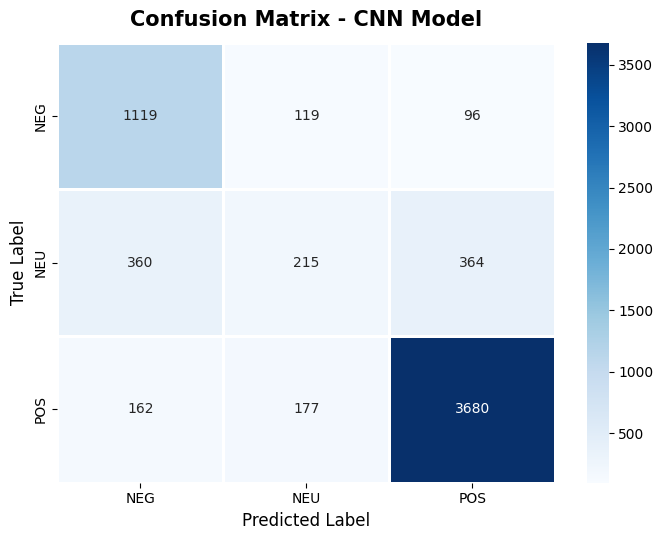

In [ ]:
# ==========================================
# PLOT CONFUSION MATRIX ONLY - CNN MODEL
# ==========================================

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Dự đoán trên tập test
y_pred_prob = model.predict(X_test, verbose=0)
y_pred = np.argmax(y_pred_prob, axis=1)

# Lấy tên nhãn
labels = encoder.classes_

# Tạo confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Vẽ hình
plt.figure(figsize=(7, 5.5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels,
    linewidths=0.8,
    linecolor="white",
    cbar=True
)

plt.title("Confusion Matrix - CNN Model", fontsize=15, fontweight="bold", pad=12)
plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("True Label", fontsize=12)

plt.tight_layout()
plt.show()

In [ ]:
# ==========================================
# SAVE TRAINED CNN MODEL
# Save model, tokenizer, label encoder, and config
# ==========================================

import pickle
import json
import os

# ==========================================
# 1. CREATE SAVE FOLDER
# ==========================================

save_dir = "saved_cnn_model"
os.makedirs(save_dir, exist_ok=True)

# ==========================================
# 2. SAVE CNN MODEL
# ==========================================

model_path = os.path.join(save_dir, "cnn_emotion_model.keras")
model.save(model_path)

# ==========================================
# 3. SAVE TOKENIZER
# ==========================================

tokenizer_path = os.path.join(save_dir, "cnn_tokenizer.pkl")

with open(tokenizer_path, "wb") as f:
    pickle.dump(tokenizer, f)

# ==========================================
# 4. SAVE LABEL ENCODER
# ==========================================

encoder_path = os.path.join(save_dir, "cnn_label_encoder.pkl")

with open(encoder_path, "wb") as f:
    pickle.dump(encoder, f)

# ==========================================
# 5. SAVE CONFIG
# ==========================================

config = {
    "max_words": max_words,
    "max_len": max_len,
    "labels": encoder.classes_.tolist()
}

config_path = os.path.join(save_dir, "cnn_config.json")

with open(config_path, "w", encoding="utf-8") as f:
    json.dump(config, f, ensure_ascii=False, indent=4)

# ==========================================
# 6. CHECK SAVED FILES
# ==========================================

print("1.", model_path)
print("2.", tokenizer_path)
print("3.", encoder_path)
print("4.", config_path)

print("\nDanh sách file trong thư mục saved_cnn_model:")
print(os.listdir(save_dir))

1. saved_cnn_model/cnn_emotion_model.keras
2. saved_cnn_model/cnn_tokenizer.pkl
3. saved_cnn_model/cnn_label_encoder.pkl
4. saved_cnn_model/cnn_config.json

Danh sách file trong thư mục saved_cnn_model:
['cnn_label_encoder.pkl', 'cnn_emotion_model.keras', 'cnn_tokenizer.pkl', 'cnn_config.json']
